In [1]:
# Dependencias - EJECUTA ESTA CELDA ANTES DE COMENZAR

# El paquete nnfs incluye la base de datos de entrenamiento que vamos a usar, y asegura que las semillas de
# los métodos random sean consistentes, para que nuestros resultados sean comparables
# %pip install -q nnfs
# %pip install -q numpy matplotlib

import nnfs
import matplotlib.pyplot as plt
import numpy as np

nnfs.init()

# Esta función la usaremos más adelante para ver los resultados de la red
# works only for model = model = [dense1, activation1, dense2, loss_activation]


def plot_prediction_performance_spiral(
    model: list | tuple,
    X,
    y,
    num_points: int = 100,
) -> None:
    """Plots the performance of the model in the spiral dataset with 3 categories"""

    def probabilities_to_rgb(probabilities_array):
        """Maps an array of probabilities to RGB colors."""

        # Ensure that probabilities sum up to 1 for all data points
        if not np.all(np.isclose(np.sum(probabilities_array, axis=1), 1.0)):
            raise ValueError("Probabilities must sum up to 1 for all data points.")

        # Map probabilities to RGB channels (0-255) for all data points
        r, g, b = (probabilities_array * 255).astype(int).T

        # Return the RGB colors as a NumPy array
        return np.column_stack((r, g, b))

    # Create a meshgrid of points in the (-1,1)x(-1,1) space
    x_val = np.linspace(-1, 1, num_points)
    y_val = np.linspace(-1, 1, num_points)

    x_grid, y_grid = np.meshgrid(x_val, y_val)

    # Flatten the grids into 1D arrays
    x_flat = x_grid.flatten()
    y_flat = y_grid.flatten()

    # Combine the flattened arrays into an Nx2 array
    XX_tuples = np.column_stack((x_flat, y_flat))

    # Perform a forward pass through the network
    input = XX_tuples
    for layer in model[:-1]:
        layer.forward(input)
        input = layer.output

    # Assumed last layer is a softmax activation + loss function
    # 'y_true' here is random since it will not be used
    # (only the output of the softmax is needed)
    model[-1].forward(input, y_true=np.array([0] * len(model[-2].output)))

    probabilities_array = model[-1].output
    rgb_colors = probabilities_to_rgb(probabilities_array)
    probs_2d = rgb_colors.reshape(num_points, num_points, 3)

    # Assumed 3 categories - change this if different
    colors = ["r" if label == 0 else "g" if label == 1 else "b" for label in y]

    plt.imshow(probs_2d, extent=(-1, 1, -1, 1), interpolation="bilinear")
    plt.scatter(X[:, 0], -X[:, 1], c=colors)
    # plt.axis('off')  # Turn off axis labels and ticks
    plt.show()  # print(rgb_colors)  # This will print the RGB color array
    # plt.pcolor(xx, yy, rgb_colors)
    # plt.show()

## Ejercicio 1: Una neurona simple

<center>
<div>
<img src="https://drive.upm.es/public.php/dav/files/04gzB6Klm7RQkH6/" width="250"/>
</div>
</center>

Calcula el output de una neurona simple con cuatro inputs: $[1.0, 2.0, 3.0, 2.5]$, donde los correspondientes pesos son $[0.2, 0.8, -0.5, 1.0]$, y el sesgo es $2.0$.

In [2]:
# SOL EJ 1

inputs = [1.0, 2.0, 3.0, 2.5]
weights = [0.2, 0.8, -0.5, 1.0]
bias = 2.0

output = [w * i for w, i in zip(weights, inputs)]

print(output)

[0.2, 1.6, -1.5, 2.5]


## Ejercicio 2: Una capa de neuronas

<center>
<div>
<img src="https://drive.upm.es/public.php/dav/files/IvPdbEiQJ9gFVxo/" width="250"/>
</div>
</center>

Calcula la salida de una capa de neuronas con cuatro entradas ($[1, 2, 3, 2.5]$) y tres neuronas:
 - Neurona 1: Pesos = $[0.2, 0.8, -0.5, 1]$, Sesgo = $2$
 - Neurona 2: Pesos = $[0.5, -0.91, 0.26, -0.5]$, Sesgo = $3$
 - Neurona 3: Pesos = $[-0.26, -0.27, 0.17, 0.87]$, Sesgo = $0.5$
  
Calcula la salida directamente sobre una lista, calculando para cada elemento las operaciones necesarias entre inputs, pesos y sesgos.


In [3]:
# SOL EJ 2

inputs = [1.0, 2.0, 3.0, 2.5]

weights1 = [0.2, 0.8, -0.5, 1.0]
weights2 = [0.5, -0.91, 0.26, -0.5]
weights3 = [-0.26, -0.27, 0.17, 0.87]

bias1 = 2
bias2 = 3
bias3 = 0.5

output = [
    sum([i * w for i, w in zip(inputs, ws)]) + b
    for ws, b in zip([weights1, weights2, weights3], [bias1, bias2, bias3])
]
output

[4.800000000000001, 1.21, 2.385]

## Ejercicio 3: Una capa de neuronas - generalización

Repite el ejercicio 2, pero utiliza un enfoque más general que permita realizar las mismas operaciones por neuronas de forma secuencial (utiliza un bucle ```for```). El formato de datos de entrada ahora es el siguiente:

In [4]:
inputs = [1, 2, 3, 2.5]
weights = [[0.2, 0.8, -0.5, 1], [0.5, -0.91, 0.26, -0.5], [-0.26, -0.27, 0.17, 0.87]]
biases = [2, 3, 0.5]

In [5]:
# SOL EJ 3

layer_outputs = []

for ws, b in zip(weights, biases):
    neuron_output = 0

    for w, i in zip(ws, inputs):
        neuron_output += w * i

    layer_outputs.append(neuron_output + b)

print(layer_outputs)

[4.8, 1.21, 2.385]


## Ejercicio 4: Prueba de eficiencia

Copia tu solución anterior, pero ahora utiliza un tamaño creciente de los datos de entrada: $n = [5, 50, 500, 5000]$. Genera listas del tamaño apropiado para los inputs, pesos y sesgos que contengan números aleatorios entre $1$ y $3$ para las entradas y sesgos y entre $-1$ y $1$ para los pesos. Utiliza una capa con $n$ neuronas. Supón distribuciones uniformes. Observa el rendimiento de tu implementación cuando $n$ crece.

In [6]:
# SOL EJ 4

n = 5000

inputs = np.random.uniform(low=1, high=3, size=n)
weights = np.random.uniform(low=-1, high=1, size=(n, n))
biases = np.random.uniform(low=1, high=3, size=n)

layer_outputs = []

for ws, b in zip(weights, biases):
    neuron_output = 0

    for w, i in zip(ws, inputs):
        neuron_output += w * i

    layer_outputs.append(neuron_output + b)

print(layer_outputs)

[np.float64(-78.0511669282067), np.float64(-180.08035358546172), np.float64(-5.5535982757079125), np.float64(12.63861421210506), np.float64(-27.08894744760306), np.float64(-102.86737186946038), np.float64(-6.27950309323455), np.float64(-28.618159920646114), np.float64(47.887415328733965), np.float64(-19.894355347959884), np.float64(-71.48496545457027), np.float64(-28.25692760499379), np.float64(8.649098326566907), np.float64(23.160203856226353), np.float64(40.42550589470791), np.float64(-13.29158259449151), np.float64(80.16288041002221), np.float64(26.704876755292737), np.float64(92.93206386473304), np.float64(155.13910875093583), np.float64(23.987401734766944), np.float64(109.26938959331758), np.float64(59.06890582908679), np.float64(-19.809346974221107), np.float64(14.102788120756875), np.float64(35.6539319813103), np.float64(16.751238047537903), np.float64(-8.513943423866875), np.float64(59.46208513799141), np.float64(99.37592251277606), np.float64(-51.18008509937684), np.float64(12

## Ejercicio 5: Una neurona simple usando ```numpy```

Reimplementa el ejercicio 1 usando el paquete ```numpy```


In [7]:
# SOL EJ 5

import numpy as np

inputs = np.array([1.0, 2.0, 3.0, 2.5])
weights = np.array([0.2, 0.8, -0.5, 1.0])
bias = 2.0

outputs = inputs @ weights + bias

print(outputs)

4.8


## Ejercicio 6: Una capa de neuronas usando ```numpy```

Reimplementa el ejercicio 2 usando el paquete ```numpy```. Realiza una prueba de eficiencia similar a la que realizaste en el ejercicio 4.


In [8]:
import numpy as np

inputs = np.array([1.0, 2.0, 3.0, 2.5])
weights = np.array(
    [[0.2, 0.8, -0.5, 1], [0.5, -0.91, 0.26, -0.5], [-0.26, -0.27, 0.17, 0.87]]
)

biases = np.array([2.0, 3.0, 0.5])

# Solución a priori antes de probar con distintos tamaños
outputs = weights @ inputs + biases
print(outputs)

[4.8   1.21  2.385]


In [9]:
# SOL EJ 6

n = 5000

inputs = np.random.uniform(low=1, high=3, size=n)
weights = np.random.uniform(low=-1, high=1, size=(n, n))
biases = np.random.uniform(low=1, high=3, size=n)

outputs = weights @ inputs + biases
print(outputs)

[-122.29839588   46.08927745   33.79767646 ...   71.2435157   119.13820879
    1.31483504]


## Ejercicio 7: Una capa de neuronas con datos en *batch*

Implementa el *forward pass* de una capa de 3 neuronas asumiendo que la entrada son datos en lote (*batch*). Es decir, la entrada ahora será una matriz, donde cada fila corresponderá a una observación. Por tanto, la salida también será de dimensión 2. Considera los datos dados a continuación:

In [10]:
import numpy as np

inputs = np.array([[1.0, 2.0, 3.0, 2.5], [2.0, 5.0, -1.0, 2.0], [-1.5, 2.7, 3.3, -0.8]])
weights = np.array(
    [[0.2, 0.8, -0.5, 1.0], [0.5, -0.91, 0.26, -0.5], [-0.26, -0.27, 0.17, 0.87]]
)
bias = np.array([2.0, 3.0, 0.5])

In [11]:
# SOL EJ 7

layer_output = inputs @ weights.T + bias

print(layer_output)

[[ 4.8    1.21   2.385]
 [ 8.9   -1.81   0.2  ]
 [ 1.41   1.051  0.026]]


## Ejercicio 8: Red neuronal con una *hidden layer*

Implementa el *forward pass* de una red con la siguiente arquitectura: una capa de entrada (4 inputs), una hidden layer de 3 neuronas y una capa de salida también con 3 neuronas. Utiliza los datos dados a continuación:

<center>
<div>
<img src="https://drive.upm.es/public.php/dav/files/IkHbjPoTjUPoGWt/" width="250"/>
</div>
</center>



In [12]:
import numpy as np

inputs = np.array([[1, 2, 3, 2.5], [2, 5, -1, 2], [-1.5, 2.7, 3.3, -0.8]])

weights = np.array(
    [[0.2, 0.8, -0.5, 1], [0.5, -0.91, 0.26, -0.5], [-0.26, -0.27, 0.17, 0.87]]
)

biases = np.array([2, 3, 0.5])

weights2 = np.array([[0.1, -0.14, 0.5], [-0.5, 0.12, -0.33], [-0.44, 0.73, -0.13]])

biases2 = np.array([-1, 2, -0.5])

In [13]:
# SOL EJ 8

layer1_outputs = inputs @ weights.T + biases
layer2_outputs = layer1_outputs @ weights2.T + biases2

print(layer2_outputs)

[[ 0.5031  -1.04185 -2.03875]
 [ 0.2434  -2.7332  -5.7633 ]
 [-0.99314  1.41254 -0.35655]]


## Ejercicio 9: Capa de neuronas usando Programación Orientada a Objetos

Crea una clase llamada ```Layer_Dense```, cuyos parámetros de entrada sean ```n_inputs``` (número de inputs a la capa) y ```n_neurons``` (número de neuronas que contiene la capa). Además, en su constructor deben inicializarse dos variables:
 - ```self.weights```: una matriz que contenga los pesos. Deben inicializarse en números aleatorios entre 0 y 0.01.
 - ```self.biases```: un vector fila que contenga los sesgos. Deben inicializarse en $0$.

Implementa un único método llamado ```forward(self, inputs)``` que, dados unos inputs a la capa, realice el *forward pass*.

In [14]:
# SOL EJ 9

import numpy as np


class Layer_Dense:

    def __init__(self, n_inputs, n_neuronas):
        self.weights = np.random.uniform(0, 0.01, size=(n_inputs, n_neuronas))
        self.biases = np.zeros(shape=(n_neuronas))

    def forward(self, inputs):
        self.output = inputs @ self.weights + self.biases


inputs = np.array([[1.0, 2.0, 3.0, 2.5], [2.0, 5.0, -1.0, 2.0], [-1.5, 2.7, 3.3, -0.8]])

dense1 = Layer_Dense(4, 3)
dense1.forward(inputs)

print(dense1.output)

[[ 0.04269814  0.05334025  0.02802839]
 [ 0.06713242  0.02735031  0.03172872]
 [ 0.02092578  0.02941497 -0.00309039]]


## Ejercicio 10: *Forward pass* de datos de entrenamiento — Triple espiral

A continuación se describe un problema de clasificación con tres categorías. La base de datos mostrada abajo ha sido generada a partir de la ecuación de 3 espirales distintas, añadiendo ruido. Se trata de un problema complejo por su alta no-linealidad. Observa toda la base de datos:

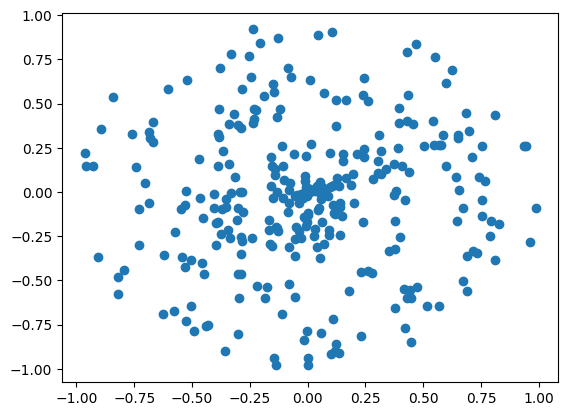

In [15]:
import matplotlib.pyplot as plt
from nnfs.datasets import spiral_data

X, y = spiral_data(samples=100, classes=3)

plt.scatter(X[:, 0], X[:, 1])
plt.show()

Resaltando por colores cada categoría se aprecia mejor su naturaleza:

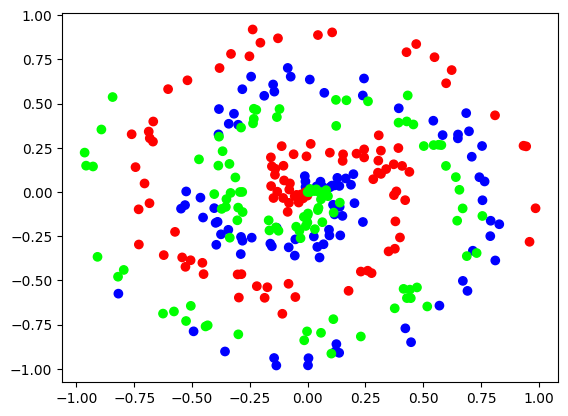

In [16]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="brg")
plt.show()

Realiza un *forward pass* de los datos de entrada ```X``` en una capa de 3 neuronas. 

In [17]:
# SOL EJ 10

import nnfs
import numpy as np

nnfs.init()

X, y = spiral_data(samples=100, classes=3)

dense1 = Layer_Dense(n_inputs=X.shape[1], n_neuronas=3)
dense1.forward(X)

print(dense1.output)
print(f"{len(dense1.output)=}")

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 5.97437380e-05  3.68895618e-05  8.37819958e-05]
 [ 1.46999714e-04  9.15808051e-05  1.40212579e-04]
 [ 2.07372351e-04  1.30936350e-04  5.65641172e-05]
 [ 2.86790374e-04  1.80765089e-04  1.03854703e-04]
 [ 2.19341363e-04  1.33933268e-04  4.29269278e-04]
 [ 4.57232830e-04  2.86837862e-04  2.75570352e-04]
 [ 5.04495603e-04  3.13935790e-04  5.10764429e-04]
 [ 5.98006575e-04  3.73010373e-04  5.33751356e-04]
 [ 6.83097597e-04  4.28781743e-04  3.91351071e-04]
 [ 7.61973701e-04  4.78020816e-04  4.58543577e-04]
 [ 5.49420743e-04  3.51005950e-04 -1.82106391e-04]
 [ 7.50892949e-04  4.75986693e-04  5.35191512e-05]
 [ 9.18770373e-04  5.79523293e-04  2.98788892e-04]
 [ 8.48342422e-04  5.38380111e-04  1.01766125e-05]
 [ 8.75700931e-04  5.56468580e-04 -4.83128718e-05]
 [ 2.25684134e-04  1.54440800e-04 -9.05890173e-04]
 [ 1.04701161e-03  6.64075673e-04  4.37535434e-05]
 [ 7.48425617e-04  4.81276231e-04 -5.01867707e-04]
 [ 1.26718662e-03  8.01315631e-

## Ejercicio 11: Función de activación ReLU

Programa una clase llamada ```Activation_ReLU``` que implemente únicamente un método ```forward(self, inputs)```. Dicho método debe aplicar la función de activación ReLU a los inputs pasados como argumento.

<center>
<div>
<img src="https://drive.upm.es/public.php/dav/files/reweQCjpTXGOQZ4/" width="350"/>
</div>
</center>


In [18]:
# SOL EJ 11


class Activation_ReLU:
    def forward(self, inputs):
        self.output = np.where(inputs > 0, inputs, 0)

## Ejercicio 12: Función de activación ```Softmax```
El objetivo de este ejercicio es llegar a una clase llamada ```Activation_Softmax``` que implemente únicamente un método ```forward(self, inputs)```. Dicho método debe aplicar la función de activación Softmax a los inputs pasados como argumento. En teoría la función Softmax se formula como

$$
S_{i, j}=\frac{e^{z_{i, j}}}{\sum_{l=1}^L e^{z_{i, l}}}
$$
siendo los $z_j$ el output de la neurona $j$ (y por tanto, input de la función de activación). El índice $i$ hace referencia a la observación $i$ considerada. 

Para conseguir una implementación robusta, haremos alguna modificación en la formulación anterior. Siguie el siguiente proceso:


 - **12.a** Dada una única observación ```layer_outputs = [4.8, 1.21, 2.385]``` (se supone salida de una capa), aplica la función Softmax anterior (de momento, no es necesario que programes ninguna clase).

In [19]:
# SOL EJ 12a
layer_outputs = [4.8, 1.21, 2.385]

[np.exp(ij) / np.sum(np.exp(layer_outputs)) for ij in layer_outputs]

[np.float64(0.8952826639572619),
 np.float64(0.02470830678209937),
 np.float64(0.0800090292606387)]

 - **12.b** Dados los siguientes datos en lote, aplica la función Softmax a cada observación.

In [20]:
# SOL EJ 12b

layer_outputs = np.array([[4.8, 1.21, 2.385], [8.9, -1.81, 0.2], [1.41, 1.051, 0.026]])

[[np.exp(ij) / np.sum(np.exp(outputs)) for ij in outputs] for outputs in layer_outputs]

[[np.float64(0.8952826639572619),
  np.float64(0.02470830678209937),
  np.float64(0.0800090292606387)],
 [np.float64(0.9998111292558762),
  np.float64(2.2316396322257094e-05),
  np.float64(0.00016655434780155166)],
 [np.float64(0.5130971642478065),
  np.float64(0.3583338992618937),
  np.float64(0.12856893649029977)]]

 - **12.c** En el proceso de exponenciación anterior, resta al input considerado el máximo valor de dicha observación. Esto pretende evitar que los valores se disparen al exponenciar (*exloding values*). Así mismo, encapsula el código anterior en una clase ```Activation_Softmax``` que implemente únicamente un método: ```forward(self, inputs)```


In [21]:
# SOL EJ 12c - 1ª parte

layer_outputs = np.array([[4.8, 1.21, 2.385], [8.9, -1.81, 0.2], [1.41, 1.051, 0.026]])

# Ponemos keepdims=True para evitar que el resultado sea de la forma (M,), que se quede como (M, 1)
max_observation = np.max(layer_outputs, axis=-1, keepdims=True)
layer_outputs = layer_outputs - max_observation

[[np.exp(ij) / np.sum(np.exp(outputs)) for ij in outputs] for outputs in layer_outputs]

[[np.float64(0.8952826639572619),
  np.float64(0.02470830678209937),
  np.float64(0.0800090292606387)],
 [np.float64(0.9998111292558762),
  np.float64(2.2316396322257084e-05),
  np.float64(0.00016655434780155155)],
 [np.float64(0.5130971642478066),
  np.float64(0.3583338992618937),
  np.float64(0.12856893649029982)]]

In [22]:
# SOL EJ 12c - 2ª parte


class Activation_Softmax:
    def forward(self, inputs):
        inputs_max = np.max(inputs, axis=-1, keepdims=True)
        exp_inputs = np.exp(inputs - inputs_max)
        sum_exps_inputs = np.sum(exp_inputs, axis=-1, keepdims=True)
        self.output = exp_inputs / sum_exps_inputs

## Ejercicio 13: *Forward pass* de una red con funciones de activación

Dado un conjunto de datos de entrada $X$, construye una red neuronal que conste de dos capas densas y funciones de activación ReLU y Softmax. El objetivo es realizar un *forward pass* a través de esta red. Los datos de entrada corresponde con los presentados en el ejercicio 10:

In [23]:
from nnfs.datasets import spiral_data

X, y = spiral_data(samples=100, classes=3)

La arquitectura de la red debe ser:
 - Input de dos features (las coordenadas de los puntos)
 - Hidden layer, con entrada de 2 valores y salida de 3. Función de activación ReLU.
 - Capa de salida, con entrada de 3 valores y salida también de 3 valores (correspondientes a las tres categorías del problema de clasificación). Función de activación Softmax.

Realiza un forward pass de los datos hasta la última función (softmax) e imprime por pantalla el output para las 5 primeras observaciones. Reutiliza las clases implementadas en ejercicios anteriores.

In [24]:
# SOL EJ 13

# Igual no había que implementar ya una clase. Me dice Gepeto que esto es lo mismo que tengo yo pero todo de golpe, sin bucles ni llamadas a funciones.
# Tan solo lo miré por encima y parece un código correcto, tengo esto por si acaso hay que hacer la clase posteriormente, que ya la tengo aquí.
#
# def forward_mlp(X, W1, b1, W2, b2):
#     Z1 = X @ W1 + b1
#     A1 = np.maximum(Z1, 0)
#     Z2 = A1 @ W2 + b2
#     exp_Z2 = np.exp(Z2 - np.max(Z2, axis=1, keepdims=True))
#     A2 = exp_Z2 / np.sum(exp_Z2, axis=1, keepdims=True)
#     return A2


class MultilayerPerceptron:
    def __init__(self, input_dim: int, output_dim: int, hidden_dims: list[int]):
        self.layers = list()

        current_dim = input_dim
        for dim in hidden_dims:
            self.layers += [
                Layer_Dense(n_inputs=current_dim, n_neuronas=dim),
                Activation_ReLU(),
            ]
            current_dim = dim

        self.layers += [
            Layer_Dense(n_inputs=current_dim, n_neuronas=output_dim),
            Activation_Softmax(),
        ]

    def forward(self, inputs):
        current_input = inputs
        for layer in self.layers:
            layer.forward(current_input)
            current_input = layer.output
        self.output = current_input

    def __repr__(self):
        lines = list()
        lines.append(f"{self.__class__.__name__}(")
        for layer in self.layers:
            lines.append(f"    {layer.__class__.__name__}({self._layer_params(layer)})")
        lines.append(")")
        return "\n".join(lines)

    def _layer_params(self, layer):
        if hasattr(layer, "weights"):
            in_features = layer.weights.shape[0]
            out_features = layer.weights.shape[1]
            return f"in_features={in_features}, out_features={out_features}"
        else:
            return ""


data = X[:5]
labels = y[:5]
mlp = MultilayerPerceptron(input_dim=2, output_dim=3, hidden_dims=[3])
mlp.forward(data)
print(mlp.output)

[[0.33333333 0.33333333 0.33333333]
 [0.33333332 0.33333334 0.33333334]
 [0.33333318 0.33333342 0.3333334 ]
 [0.33333313 0.33333344 0.33333342]
 [0.33333305 0.33333349 0.33333346]]


## Ejercicio 14: Función de pérdidas — entropía cruzada. Caso particular

Imagina que estamos tratando de clasificar entre las categorías "perro", "gato" o "humano". Un perro es la clase 0 (en el índice 0), un gato la clase 1 (índice 1) y un humano la clase 2 (índice 2). Supongamos que tenemos una arquitectura como la del ejercicio anterior y que tenemos un batch de tres observaciones, que han dado lugar a los siguientes valores de salida en la última capa:

In [25]:
softmax_outputs = np.array([[0.7, 0.1, 0.2], [0.1, 0.5, 0.4], [0.02, 0.9, 0.08]])

Recuerda que estos valroes representan la **confianza del modelo en cada clase**, para cada observación. Disponemos también de las etiquetas (valores objetivo) para estas tres observaciones: son un perro, un gato y un gato:

In [26]:
class_targets = [0, 1, 1]  # perro, gato, gato

La fórmula para calcular la entropía cruzada categórica de *y* (distribución real/deseada) e *y-hat* (distribución predicha) es:
$$
L_i=-\sum_j y_{i, j} \log \left(\hat{y}_{i, j}\right)
$$
donde $L_i$ indica el valor de pérdida de la muestra, $i$ es la muestra $i$-ésima del conjunto, $j$ es la hace referencia al valor $j$-ésimo en la salida, $y$ son los valores objetivo (conocidos de antemano) e $\hat{y}$ son los valores predichos (salida de la red).

Calcula la entropía cruzada categórica para cada observación del batch anterior, así como una media para todo el batch.

In [27]:
# SOL EJ 14

# Se podía calcular con list comprehension pero usar un range queda más elegante
probabilities_of_target = softmax_outputs[range(len(softmax_outputs)), class_targets]
negative_log_probs = -np.log(probabilities_of_target)
average_loss = np.mean(negative_log_probs)

probabilities_of_target, negative_log_probs, average_loss

(array([0.7, 0.5, 0.9]),
 array([0.35667494, 0.69314718, 0.10536052]),
 np.float64(0.38506088005216804))

## Ejercicio 15: Función de pérdidas — entropía cruzada usando POO

Observa la siguiente clase abstracta:

In [28]:
from abc import ABC, abstractmethod
import numpy as np


class Loss(ABC):

    @abstractmethod
    def forward(self, output, y):
        pass

    def calculate(self, output, y):
        """
        Return sample losses (mean)
         - output: output of the last layer of the network
         - y: ground truth
        """
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        return data_loss

 - **15.a** A partir del ejercicio 14, implementa una clase llamada ```Loss_CategoricalCrossentropy``` que herede de la clase abstracta anterior e implemente el método ```forward```, para el caso de una función de pérdida tipo entropía cruzada categórica.

In [29]:
# SOL EJ 15a


class Loss_CategoricalCrossentropy(Loss):

    def forward(self, output, y):
        sample = len(output)

        # Con la siguiente línea evitamos inestabilidades en la evaluación del logaritmo
        y_pred_clipped = np.clip(output, 1e-7, 1 - 1e-7)

        correct_confidences = y_pred_clipped[range(sample), y]
        negative_log_probs = -np.log(correct_confidences)

        return np.mean(negative_log_probs)

 - **15.b** Repite el *forward pass* del ejercicio 13, pero incluye el cálculo final de la función de pérdidas usando la implementación anterior

In [30]:
# SOL EJ 15b

mlp = MultilayerPerceptron(input_dim=2, output_dim=3, hidden_dims=[3])
loss_function = Loss_CategoricalCrossentropy()

mlp.forward(data)

loss_mean = loss_function.forward(output=mlp.output, y=labels)

print(f"Predicciones SoftMax:\n{mlp.output}")
print(f"Pérdida media: {loss_mean}")

Predicciones SoftMax:
[[0.33333333 0.33333333 0.33333333]
 [0.3333334  0.33333324 0.33333336]
 [0.3333336  0.33333312 0.33333328]
 [0.33333369 0.33333296 0.33333334]
 [0.33333383 0.33333286 0.33333331]]
Pérdida media: 1.0986115776358485


 - **15.c** Aunque la pérdida es una métrica útil para optimizar un modelo, hay otra métrica que se suele utilizar en la práctica junto con la pérdida: la *precisión*, que describe con qué frecuencia la mayor confianza corresponde a la clase correcta. Añade al código del apartado 'b' el cálculo de la precisión.

In [31]:
# SOL EJ 15c


class PrecisionMetric:

    def __call__(self, y_pred, y_true):
        predictions = np.argmax(y_pred, axis=1)

        # Por si y_true está en formato one-hot
        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)

        accuracy = np.mean(predictions == y_true)
        return accuracy


precision_function = PrecisionMetric()
print(f"Precisión del modelo: {precision_function(mlp.output, labels)*100:.2f}%")

Precisión del modelo: 100.00%


## Ejercicio 16: Optimización — modificación aleatoria de pesos (I)

Observa los siguientes datos de entrenamiento, que también definen un problema de clasificación multiclase, pero de una naturaleza más sencilla que el de la triple espiral visto hasta ahora

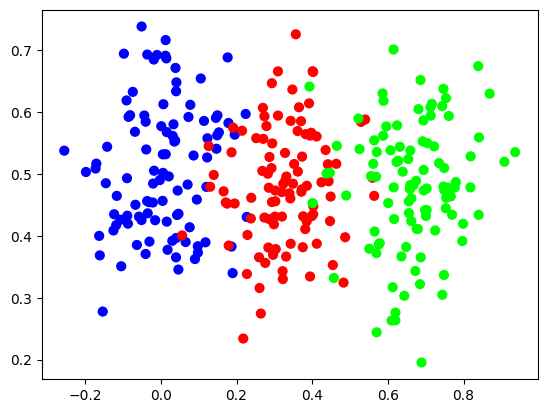

In [32]:
import matplotlib.pyplot as plt
import nnfs
from nnfs.datasets import vertical_data

nnfs.init()

X, y = vertical_data(samples=100, classes=3)

plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap="brg")
plt.show()

Utilizando la estructura computacional del ejercicio anterior, realiza un proceso iterativo (máximo 10000 iteraciones) en el que se vayan cambiando los pesos y sesgos de ambas capas de forma aleatoria (distribución normal de media 0 y varianza 0.05). Almacena el resultado que dé lugar a una menor pérdida. Comenta el decrecimiento de la función de pérdidas durante el proceso.

In [33]:
# SOL EJ 16
# Pista - usa 0.05 * np.random.randn para generar los arrays de números aleatorios que necesites <======= Así no creamos una distribución uniforme??? <===== Vale no, eso sería con np.random.rand, no con randn
nnfs.init()

# Create dataset
X, y = vertical_data(samples=100, classes=3)

# Create model
dense1 = Layer_Dense(2, 3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3, 3)
activation2 = Activation_Softmax()

# Create loss function
loss_function = Loss_CategoricalCrossentropy()

# Create precision metric
precision_metric = PrecisionMetric()

lowest_loss = np.inf
best_dense1_weights = np.empty(shape=dense1.weights.shape, dtype=np.float32)
best_dense1_biases = np.empty(shape=dense1.biases.shape, dtype=np.float32)
best_dense2_weights = np.empty(shape=dense2.weights.shape, dtype=np.float32)
best_dense2_biases = np.empty(shape=dense2.biases.shape, dtype=np.float32)

N = 10000
padding_width = int(np.floor(np.log10(N))) + 1
for iteration in range(N):
    dense1.weights = np.random.normal(0, 0.05, size=dense1.weights.shape)
    dense1.biases = np.random.normal(0, 0.05, size=dense1.biases.shape)
    dense2.weights = np.random.normal(0, 0.05, size=dense2.weights.shape)
    dense2.biases = np.random.normal(0, 0.05, size=dense2.biases.shape)

    # Forward pass
    dense1.forward(X)
    dense2.forward(dense1.output)

    # Loss
    loss = loss_function.forward(dense2.output, y)

    # Precision
    prec = precision_metric(dense2.output, y)

    # Parameter update
    if loss < lowest_loss:
        print(
            f"New set of weights found | Iteration:{iteration:0{padding_width}d} | Loss: {loss:.5f}"
        )
        lowest_loss = loss
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()

New set of weights found | Iteration:00000 | Loss: 3.28177
New set of weights found | Iteration:00025 | Loss: 3.13998
New set of weights found | Iteration:00042 | Loss: 2.85946
New set of weights found | Iteration:00048 | Loss: 2.85820
New set of weights found | Iteration:00258 | Loss: 2.81857
New set of weights found | Iteration:00360 | Loss: 2.75858
New set of weights found | Iteration:00810 | Loss: 2.69972
New set of weights found | Iteration:01052 | Loss: 2.39725
New set of weights found | Iteration:06023 | Loss: 2.32976
New set of weights found | Iteration:08814 | Loss: 2.27239


Durante el proceso de búsqueda aleatoria de pesos, podemos observar un decaimiento progresivo de la función de pérdidas. Esto indica que, aunque los pesos se generan al azar en cada iteración sin ningún tipo de optimización dirigida, **ocasionalmente surgen configuraciones que producen un mejor ajuste al conjunto de datos**, lo que se refleja en una menor pérdida. La reducción no es continua ni suave, es completamente aleatoria, ya que los pesos se muestrean de forma independiente en cada iteración. En consecuencia, el descenso de la pérdida no sigue un patrón típico de entrenamiento, sino que depende completamente de la suerte de encontrar combinaciones más favorables.

## Ejercicio 17: Optimización — modificación aleatoria de pesos (II)

 - **17.a** Repite el ejercicio anterior con un enfoque ligeramente distinto: en lugar de fijar nuevos parámetros elegios al azar en cada iteración, suma una fracción aleatoria (distribución normal de media 0 y varianza 0.05) a los parámetros actuales y comprueba si esos nuevos valores dan lugar a una pérdida menor. Comenta si este enfoque funciona mejor o peor que el anterior.


In [34]:
# SOL EJ 17a

nnfs.init()

# Create dataset
X, y = vertical_data(samples=100, classes=3)

# Create model
dense1 = Layer_Dense(2, 3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3, 3)
activation2 = Activation_Softmax()

# Create loss function
loss_function = Loss_CategoricalCrossentropy()

# Create precision metric
precision_metric = PrecisionMetric()

lowest_loss = np.inf
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

N = 10000
padding_width = int(np.floor(np.log10(N))) + 1
for iteration in range(N):
    dense1.weights += np.random.normal(0, 0.05, size=dense1.weights.shape)
    dense1.biases += np.random.normal(0, 0.05, size=dense1.biases.shape)
    dense2.weights += np.random.normal(0, 0.05, size=dense2.weights.shape)
    dense2.biases += np.random.normal(0, 0.05, size=dense2.biases.shape)

    # Forward pass
    dense1.forward(X)
    dense2.forward(dense1.output)

    # Loss
    loss = loss_function.forward(dense2.output, y)

    # Precision
    prec = precision_metric(dense2.output, y)

    # Parameter update
    if loss < lowest_loss:
        print(
            f"New set of weights found | Iteration:{iteration:0{padding_width}d} | Loss: {loss:.5f} | Precision: {prec*100:.2f}%"
        )
        lowest_loss = loss
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()

New set of weights found | Iteration:00000 | Loss: 3.27031 | Precision: 33.33%
New set of weights found | Iteration:00001 | Loss: 3.16549 | Precision: 34.33%
New set of weights found | Iteration:00015 | Loss: 3.10376 | Precision: 33.33%
New set of weights found | Iteration:00061 | Loss: 2.96876 | Precision: 33.33%
New set of weights found | Iteration:00066 | Loss: 2.76982 | Precision: 33.33%
New set of weights found | Iteration:00069 | Loss: 1.52604 | Precision: 35.33%
New set of weights found | Iteration:06880 | Loss: 0.06844 | Precision: 56.67%
New set of weights found | Iteration:06881 | Loss: 0.00000 | Precision: 58.33%


En este segundo experimento, el comportamiento de la función de pérdidas es muy distinto al del caso anterior. En lugar de reiniciar los pesos en cada iteración, se realiza una modificación incremental añadiendo pequeñas perturbaciones aleatorias. Como resultado, el modelo explora más eficientemente el espacio de parámetros, manteniendo cierta continuidad entre las configuraciones sucesivas. Esto se refleja claramente en los resultados, donde la pérdida inicial desciende de forma mucho más pronunciada hasta alcanzar valores cercanos a cero. Por tanto, **este enfoque resulta más eficaz que el anterior**. Aunque sigue sin implicar un proceso de entrenamiento formal, acumular pequeños cambios permite aproximarse gradualmente a regiones del espacio de parámetros con menores valores de pérdida, en lugar de depender exclusivamente del azar independientemente de cada iteración.

 - **17.b** Prueba también este enfoque con los datos de la triple espiral.

In [35]:
# SOL EJ 17b

nnfs.init()

# Create dataset
X, y = spiral_data(samples=100, classes=3)

# Create model
dense1 = Layer_Dense(2, 3)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(3, 3)
activation2 = Activation_Softmax()

# Create loss function
loss_function = Loss_CategoricalCrossentropy()

# Create precision metric
precision_metric = PrecisionMetric()

lowest_loss = np.inf
best_dense1_weights = dense1.weights.copy()
best_dense1_biases = dense1.biases.copy()
best_dense2_weights = dense2.weights.copy()
best_dense2_biases = dense2.biases.copy()

N = 10000
padding_width = int(np.floor(np.log10(N))) + 1
for iteration in range(N):
    dense1.weights += np.random.normal(0, 0.05, size=dense1.weights.shape)
    dense1.biases += np.random.normal(0, 0.05, size=dense1.biases.shape)
    dense2.weights += np.random.normal(0, 0.05, size=dense2.weights.shape)
    dense2.biases += np.random.normal(0, 0.05, size=dense2.biases.shape)

    # Forward pass
    dense1.forward(X)
    dense2.forward(dense1.output)

    # Loss
    loss = loss_function.forward(dense2.output, y)

    # Parameter update
    if loss < lowest_loss:
        print(
            f"New set of weights found | Iteration:{iteration:0{padding_width}d} | Loss: {loss:.5f} | Precision: {prec*100:.2f}%"
        )
        lowest_loss = loss
        best_dense1_weights = dense1.weights.copy()
        best_dense1_biases = dense1.biases.copy()
        best_dense2_weights = dense2.weights.copy()
        best_dense2_biases = dense2.biases.copy()

New set of weights found | Iteration:00000 | Loss: 16.11810 | Precision: 33.33%
New set of weights found | Iteration:00003 | Loss: 12.72917 | Precision: 33.33%
New set of weights found | Iteration:00004 | Loss: 9.01878 | Precision: 33.33%
New set of weights found | Iteration:00005 | Loss: 7.43514 | Precision: 33.33%
New set of weights found | Iteration:00006 | Loss: 7.17459 | Precision: 33.33%
New set of weights found | Iteration:00011 | Loss: 6.60284 | Precision: 33.33%
New set of weights found | Iteration:00012 | Loss: 6.38739 | Precision: 33.33%
New set of weights found | Iteration:00014 | Loss: 6.27310 | Precision: 33.33%
New set of weights found | Iteration:00015 | Loss: 6.25174 | Precision: 33.33%
New set of weights found | Iteration:00816 | Loss: 6.22242 | Precision: 33.33%
New set of weights found | Iteration:01277 | Loss: 6.19873 | Precision: 33.33%
New set of weights found | Iteration:01278 | Loss: 6.18688 | Precision: 33.33%
New set of weights found | Iteration:01279 | Loss:

En este caso, al usar el conjunto `spiral_data`, el comportamiento cambia claramente respecto a los anteriores. La función de pérdidas comienza con un valor muy alto y desciende de forma progresiva hasta un valor más bajo (pero considerablemente alto), lo que muestra cierta mejora, pero sin llegar a valores bajos. Esto sugiere un  mínimo ajuste de los datos para "adaptarse" (no es una adaptación, simplemente por ir cogiendo poco a poco pesos más )

La precisión permanece constante en 33.33 %, lo que indica que el modelo no consigue aprender ninguna estructura útil: sus predicciones son básicamente aleatorias entre las tres clases y tan solo predice bien una clase. Esto era previsible, ya que el conjunto en espiral es mucho más complejo y no lineal, por lo que requiere una optimización guiada (por gradiente) para ajustar los pesos de forma significativa.

## Ejercicio 18: Introducción a la *backpropagation*

La siguiente imagen corresponde a una simple neurona + f. activación, con 3 inputs. Los valores de inputs, pesos y sesgo se han fijado aleatoriamente. En la imagen también se indica en rojo el valor del gradiente recibido de una capa posterior (en este ejemplo, $1$):

<center>
<div>
<img src="https://drive.upm.es/public.php/dav/files/nJHrGFJQ8VVuZK7/" width="500"/>
</div>
</center>

Pensemos en esta neurona como una gran función, cuyas variables independientes o parámetros de entrada son los inputs, pesos y sesgo. Esta gran función consiste en varias funciones más simples: hay una multiplicación de inputs y pesos, suma de estos valores y el sesgo, así como una la función activación ReLU - 3 funciones encadenadas en total:
$$
\operatorname{ReLU}\left(\operatorname{sum}\left(\operatorname{mul}\left(x_0, w_0\right), \operatorname{mul}\left(x_1, w_1\right), \operatorname{mul}\left(x_2, w_2\right), b\right)\right)
$$
Para calcular cómo afecta cada variable al resultado, debemos calcular sus derivadas parciales. Como hay varias funciones combinadas, debemos aplicar la regla de la cadena. 

Calcula cómo impacta en **el input $x_0$** el gradiente recibido, es decir:

$$
\begin{aligned}
& \frac{\partial}{\partial x_0}\left[\operatorname{ReLU}\left(\operatorname{sum}\left(\operatorname{mul}\left(x_0, w_0\right), \operatorname{mul}\left(x_1, w_1\right), \operatorname{mul}\left(x_2, w_2\right), b\right)\right)\right] = \\

& \frac{d\operatorname{ReLU}}{d\operatorname{sum}} \cdot \left(\frac{d\operatorname{sum}}{d\operatorname{mul}(x_0, w_0)} \cdot \frac{d\operatorname{mul}(x_0, w_0)}{dx_0} + \frac{d\operatorname{sum}}{d\operatorname{mul}(x_1, w_1)} \cdot \frac{d\operatorname{mul}(x_1, w_1)}{dx_0} + \frac{d\operatorname{sum}}{d\operatorname{mul}(x_2, w_2)} \cdot \frac{d\operatorname{mul}(x_2, w_2)}{dx_0} + \frac{d\operatorname{sum}}{db} \cdot \frac{db}{dx_0}\right) = \\

& \frac{d\operatorname{ReLU}}{d\operatorname{sum}} \cdot \left( 1\times w_0 + 1 \times 0 + 1 \times 0 + 1 \times 0 \right)  = \frac{d\operatorname{ReLU}}{d\operatorname{sum}} \cdot w_0 = \begin{cases} w_0,~si~sum >=0 \\ 0,~si~sum < 0\end{cases}
\end{aligned}
 $$

In [36]:
# SOL EJ 18 - Desarrollo en la celda de encima

## Ejercicio 19: Capa densa con *backpropagation*

Extiende la implementación que hiciste en el ejercicio 9, incluyendo un nuevo método llamado ```backward(self, dvalues)``` que implemente el backward pass (excluyendo la función de activación). El parámetro ```dvalues``` es una matriz donde cada fila se refiere a una observación del batch, y cada elemento de dicha fila es el gradiente llegado de aguas abajo. Dicho método debe calcular los valores ```self.dweights```, ```self.dbiases``` y ```self.dinputs``` que recogen las distintas derivadas parciales para cada parámetro. Presta atención a las dimensiones.

In [37]:
# SOL EJ 19

import numpy as np


class Layer_Dense:

    def __init__(self, n_inputs, n_neuronas):
        self.weights = 0.01 * np.random.randn(n_inputs, n_neuronas)
        self.biases = np.zeros((1, n_neuronas))

    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = self.inputs.T @ dvalues  # (n_imputs, n_neuronas)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)  # (1, n_neuronas)
        self.dinputs = dvalues @ self.weights.T  # (batch_size, n_inputs)

## Ejercicio 20: ReLU con *backpropagation*

Extiende la implementación que hiciste en el ejercicio 11, incluyendo un nuevo método llamado ```backward(self, dvalues)``` que implemente el backward pass. El parámetro ```dvalues``` es el gradiente que le llega de capas posteriores. El método debe calcular los valores ```self.dinputs```.

In [38]:
# SOL EJ 20


class Activation_ReLU:

    def forward(self, inputs):

        self.inputs = inputs
        self.output = np.maximum(0, inputs)

    def backward(self, dvalues):
        self.dinputs = np.where(self.inputs > 0, dvalues, 0)

## Ejercicio 21: Función de pérdidas con *backpropagation*

Extiende la implementación que hiciste en el ejercicio 15, incluyendo un nuevo método llamado ```backward(self, y_hat, y_true)``` que implemente el backward pass. El parámetro ```y_hat``` son los valores predichos ($\hat{y}_{i,j}$) y ```y_true``` son los valores objetivo. El método debe calcular los valores ```self.dinputs```, el vector derivada respecto a los inputs. Ten en cuenta lo siguiente:
 - Debes convertir los ```y_true``` en *one-hot* vectors.
 - Una vez calcules la derivada según el desarrollo teórico, normaliza el resultado. Esto evitará problemas con muestras grandes en pasos posteriores. Simplemente divide el resultado final por la longitud de la muestra (```len(y_hat)```)

In [39]:
# SOL EJ 21


class Loss_CategoricalCrossentropy(Loss):

    def forward(self, output, y):
        sample = len(output)

        # Con la siguiente línea evitamos inestabilidades en la evaluación del logaritmo
        y_pred_clipped = np.clip(output, 1e-7, 1 - 1e-7)

        correct_confidences = y_pred_clipped[range(sample), y]
        negative_log_probs = -np.log(correct_confidences)

        return np.mean(negative_log_probs)

    def backward(self, y_hat, y_true):
        # Número de muestras -> obtenla apropiadamente de las dimensiones de y_hat
        samples = y_hat.shape[0]

        # Número de etiquetas en cada muestra -> obtenla apropiadamente de las dimensiones de y_hat. Se usará en la siguiente operación
        labels = y_hat.shape[1]

        # y_true inicialmente es un array 1D de índices de clases, necesitamos convertirlo a vectores one-hot
        y_true_oh = np.zeros((samples, labels))
        y_true_oh[np.arange(samples), y_true] = 1

        # Calcula el gradiente directamente, aprovechando las propiedades de los arrays de numpy
        self.dinputs = -np.divide(y_true_oh, y_hat)

        # Normaliza el gradiente
        self.dinputs /= samples

## Ejercicio 22: SoftMax con *backpropagation*

Se pretende extender la implementación que hiciste en el ejercicio 12, incluyendo un nuevo método llamado ```backward(self, dvalues)``` que implemente el backward pass. El parámetro ```dvalues``` es el gradiente que le llega de capas posteriores. El método debe calcular los valores ```self.dinputs```.
 - **22a.** Comienza calculando un caso particular. Supón que la salida de la función Softmax ha sido ```softmax_output = [0.7, 0.1, 0.2]```. El resultado debe ser una matriz (el Jacobiano) de dimensión $3x3$.

In [40]:
# SOL 22a

import numpy as np

single_output = np.array(
    [
        [
            0.7,
            0.1,
            0.2,
        ]
    ]
)

jacobian_calculator = lambda s: np.diagflat(s) - np.outer(
    s, s
)  # Es lo mismo que poner (s.T@s) porque s va a ser un vector columna (1, N)
jacobian = jacobian_calculator(single_output)

print(jacobian)

[[ 0.21 -0.07 -0.14]
 [-0.07  0.09 -0.02]
 [-0.14 -0.02  0.16]]


 - **22b.** Generaliza el código anterior. Extiende la clase del ejercicio 12 con el método llamado ```backward(self, dvalues)```. A continuación se incluye una plantilla de desarrollo que debe ser completada. Recuerda copiar el resto de métodos de la clase.

In [41]:
# SOL 22b


class Activation_Softmax:

    def forward(self, inputs):
        inputs_max = np.max(inputs, axis=-1, keepdims=True)
        exp_inputs = np.exp(inputs - inputs_max)
        sum_exps_inputs = np.sum(exp_inputs, axis=-1, keepdims=True)
        self.output = exp_inputs / sum_exps_inputs

    # Paso hacia atrás
    def backward(self, dvalues):
        # Crear un array no inicializado con la misma dimensión que dvalues
        self.dinputs = np.empty_like(dvalues)

        # Enumerar salidas y gradientes
        for index, (single_output, single_dvalues) in enumerate(
            zip(self.output, dvalues)
        ):
            # Aplanar el array de salida - usa 'reshape'
            single_output = single_output.reshape(-1)

            # Calcular la matriz Jacobiana de la salida
            jacobian_matrix = jacobian_calculator(single_output)

            # Calcular el gradiente por muestra y añadirlo al array de gradientes por muestra
            self.dinputs[index] = jacobian_matrix @ single_dvalues

## Ejercicio 23: Softmax + entropía cruzada

Al calcular juntas las derivadas de la función Softmax y la función de pérdidas de entropía cruzada categórica, los cáluclos se simplifican notablemente. Implementa el método que hace el *backward pass* (i.e. ```backward(self, dvalues, y_true)```) de nueva clase llamada ```Activation_Softmax_Loss_CategoricalCrossentropy``` (el resto de métodos se dan ya implementados). Recuerda normalizar el resultado dividiéndolo por el número de muestras (```len(dvalues)```) para evitar problemas en pasos futuros.

In [42]:
# SOL EJ 23


class Activation_Softmax_Loss_CategoricalCrossentropy:

    def __init__(self):
        self.activation = Activation_Softmax()
        self.loss = Loss_CategoricalCrossentropy()

    def forward(self, inputs, y_true):
        self.activation.forward(inputs)

        self.output = self.activation.output
        return self.loss.calculate(self.output, y_true)

    def backward(self, y_hat, y_true):
        samples = y_hat.shape[0]

        if y_true.ndim == 1:
            y_true = (np.arange(y_hat.shape[1]) == y_true[:, None]).astype(float)

        self.dinputs = (y_hat - y_true) / samples

## Ejercicio 24: Comprobación Softmax + entropía cruzada

Se pretende comprobar si el *backpropagation* combinado (Softmax + entropía cruzada) devuelve los mismos valores en comparación con cuando retropropagamos gradientes a través de ambas funciones por separado. Para este ejemplo, vamos a crear una salida de la función Softmax y algunos valores objetivo. Retropropágalos utilizando ambas soluciones, y comprueba que obtienes los mismos resultados

In [43]:
# SOL EJ 24

import numpy as np
import nnfs

nnfs.init()

# Valores de ejemplo: salidas de la función Softmax y etiquetas de clase objetivo
softmax_outputs = np.array([[0.7, 0.1, 0.2], [0.1, 0.5, 0.4], [0.02, 0.9, 0.08]])
class_targets = np.array([0, 1, 1])

# Método Combinando Softmax y entropía cruzada en un solo objeto
softmax_loss = Activation_Softmax_Loss_CategoricalCrossentropy()
softmax_loss.backward(y_hat=softmax_outputs, y_true=class_targets)
dinputs_combined = softmax_loss.dinputs

# Método separando Softmax y entropía cruzada
activation = Activation_Softmax()
loss = Loss_CategoricalCrossentropy()

activation.output = softmax_outputs.copy()
loss.forward(output=softmax_outputs, y=class_targets)
loss.backward(y_hat=softmax_outputs, y_true=class_targets)
activation.backward(dvalues=loss.dinputs)

dinputs_separate = activation.dinputs

# Imprimir los gradientes obtenidos
print(f"Gradients: combined loss and activation:\n{dinputs_combined}")
print(f"Gradients: separate loss and activation:\n{dinputs_separate}")

Gradients: combined loss and activation:
[[-0.1         0.03333333  0.06666667]
 [ 0.03333333 -0.16666667  0.13333333]
 [ 0.00666667 -0.03333333  0.02666667]]
Gradients: separate loss and activation:
[[-0.1         0.03333333  0.06666667]
 [ 0.03333333 -0.16666667  0.13333333]
 [ 0.00666667 -0.03333333  0.02666667]]


## Ejercicio 25: *Backward pass* de toda la red

Realiza un *backward pass* de la red que usaste en el ejercicio *15b*. 

In [44]:
# SOL EJ 25
# El ejercicio 15 propoponía: Repite el *forward pass* del ejercicio 13, pero incluye el cálculo final de la función de pérdidas usando la implementación anterior
# Creo que no había que hacer una clase para el MLP, que era hacerlo todo a mano, pero esto queda más chulo. Si luego toca hacerlo al menos ya lo tengo implementado
# El ejercicio 13 proponía: Dado un conjunto de datos de entrada $X$, construye una red neuronal que conste de dos capas densas y funciones de activación ReLU y Softmax

from nnfs.datasets import spiral_data

X, y = spiral_data(samples=100, classes=3)


# Defino de nuevo la arquitectura de la clase MultilayerPerceptron porque aún no tiene el método `backward` implementado
class MultilayerPerceptron:
    def __init__(self, input_dim: int, output_dim: int, hidden_dims: list[int]):
        self.layers = list()

        current_dim = input_dim
        for dim in hidden_dims:
            self.layers += [
                Layer_Dense(n_inputs=current_dim, n_neuronas=dim),
                Activation_ReLU(),
            ]
            current_dim = dim

        self.layers += [
            Layer_Dense(n_inputs=current_dim, n_neuronas=output_dim),
            Activation_Softmax(),
        ]

    def __repr__(self):
        lines = list()
        lines.append(f"{self.__class__.__name__}(")
        for layer in self.layers:
            lines.append(f"    {layer.__class__.__name__}({self._layer_params(layer)})")
        lines.append(")")
        return "\n".join(lines)

    def _layer_params(self, layer:Layer_Dense):
        if hasattr(layer, "weights"):
            in_features = layer.weights.shape[0]
            out_features = layer.weights.shape[1]
            return f"in_features={in_features}, out_features={out_features}"
        else:
            return ""

    def forward(self, inputs):
        current_input = inputs
        for layer in self.layers:
            layer.forward(current_input)
            current_input = layer.output
        self.output = current_input

    def backward(self, dvalues):
        for layer in reversed(self.layers):
            layer.backward(dvalues)
            dvalues = layer.dinputs


# Esta es la solución del ejercicio 15b
mlp = MultilayerPerceptron(input_dim=2, output_dim=3, hidden_dims=[3])
print(mlp)

# Aprovechando que tenemos el cálculo de la loss + softmax lo añadimos aquí
softmax_loss = Activation_Softmax_Loss_CategoricalCrossentropy()

mlp.forward(data)
loss = softmax_loss.forward(inputs=mlp.output, y_true=labels)
print(f"Predicciones SoftMax:\n{mlp.output}")
print(f"Pérdida media: {loss}")

# ====== Hasta aquí la solución del ejercicio 15b ====== #
# Añadimos ahora el cálculo de paso de backward
softmax_loss.backward(y_hat=mlp.output, y_true=labels)
dvalues = softmax_loss.dinputs
mlp.backward(dvalues)

# Mostrar gradientes de todas las capas Dense
for i, layer in enumerate(mlp.layers):
    if isinstance(layer, Layer_Dense):
        print(f"\nGradientes de la capa Dense {i}:")
        print(f"dweights:\n{layer.dweights}")
        print(f"dbiases:\n{layer.dbiases}")

MultilayerPerceptron(
    Layer_Dense(in_features=2, out_features=3)
    Activation_ReLU()
    Layer_Dense(in_features=3, out_features=3)
    Activation_Softmax()
)
Predicciones SoftMax:
[[0.33333334 0.33333334 0.33333334]
 [0.33333328 0.33333328 0.33333337]
 [0.33333293 0.33333296 0.33333412]
 [0.3333329  0.33333293 0.33333418]
 [0.33333266 0.33333272 0.33333462]]
Pérdida media: 1.0986125469207764

Gradientes de la capa Dense 0:
dweights:
[[-2.45039342e-06  8.59436317e-06  0.00000000e+00]
 [ 3.80326304e-06  2.38362316e-05  0.00000000e+00]]
dbiases:
[[0.00044791 0.00084213 0.        ]]

Gradientes de la capa Dense 2:
dweights:
[[-6.09859332e-07  3.04929584e-07  3.04929748e-07]
 [-4.77117941e-05  2.38557883e-05  2.38560056e-05]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00]]
dbiases:
[[-0.22222222  0.11111082  0.1111114 ]]


## Ejercicio 26: Optimizador — Descenso del gradiente

Programa una clase llamada ```Optimizer_SGD``` que implemente el optimizador de descenso de gradiente. Pasa a su constructor un parámetro ```learning_rate``` por defecto de $1$. Dicha clase deberá contener un único método llamado ```update_params(layer)``` al que se le pase una capa y aplique sus correspondientes gradientes a la actualización de sus parámetros.

In [45]:
# SOL EJ 26


class Optimizer_SGD:

    def __init__(self, learning_rate=1.0):
        self.lr = learning_rate

    def update_params(self, layer: Layer_Dense):
        layer.weights += -self.lr * layer.dweights
        layer.biases += -self.lr * layer.dbiases

## Ejercicio 27: Optimización sobre el caso de la triple espiral

Partiendo del código al que llegaste en el ejercicio 25, añade un optimizador que actualice los parámetros de la red. Realiza 10000 iteraciones (*epoch*). Observa como evoluciona la precisión y las pérdidas a lo largo del entrenamiento. **De ahora en adelante usa una arquitectura con 64 neuronas por capa.**

100%|██████████| 10000/10000 [00:05<00:00, 1923.92it/s, loss=0.9305, prec=0.6567]


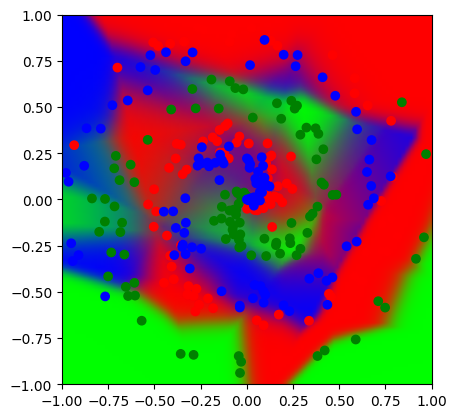

In [46]:
# SOL EJ 27
# En el ejercicio anterior empleé una clase diseñada por mí para el MLP, no hice las capas una a una a mano, así que lo hago aquí
from tqdm import tqdm

nnfs.init()
X, y = spiral_data(samples=100, classes=3)

dense1 = Layer_Dense(n_inputs=X.shape[1], n_neuronas=64)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(n_inputs=64, n_neuronas=3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

optimizer = Optimizer_SGD()
precision_func = PrecisionMetric()

# Entrenamiento
n_steps = int(1e4)
pbar = tqdm(range(n_steps))
for step in pbar:
    # Paso de forward
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss_activation.forward(dense2.output, y)

    # Paso de backward
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # Actualización de los pesos
    optimizer.update_params(layer=dense2)
    optimizer.update_params(layer=dense1)

    if step % 1000 == 0:
        loss_val = loss_activation.loss.calculate(output=loss_activation.output, y=y)
        prec_metric = precision_function(y_pred=loss_activation.output, y_true=y)
        pbar.set_postfix({"loss": f"{loss_val:.4f}", "prec": f"{prec_metric:.4f}"})


# Este código a continuación te ayudará a visualizar los resultados de la red
# (asegúrate que el la lista 'model' contiene los mismo nombres para las
# distintas capas, y si no es así actualiza dicha variable con el naming usado)
model = [dense1, activation1, dense2, loss_activation]
num_points = 100
plot_prediction_performance_spiral(model, X, y, num_points)

## Ejercicio 28: Misma solución utilizando ```keras```

Busca documentación sobre cómo implementar redes neuronales con el módulo ```tf.keras``` (echa un vistazo por ejemplo a [este enlace](https://stackoverflow.com/questions/64689483/how-to-do-multiclass-classification-with-keras), o [este otro](https://machinelearningmastery.com/multi-class-classification-tutorial-keras-deep-learning-library/)). Crear una arquitectura similar a la usada en el ejercicio anterior, directamente usando las herramientas disponibles en dicho paquete. 

In [47]:
# %pip install -q tensorflow
# SOL EJ 28

from tensorflow import keras
from keras.utils import to_categorical
from keras.layers import Input, Dense
from keras.models import Model
from keras.optimizers import SGD
from keras.losses import CategoricalCrossentropy
from keras.metrics import Precision

nnfs.init()

n_classes = 3
X, y = spiral_data(samples=100, classes=n_classes)
y = to_categorical(y)

# También se puede hacer con keras.Sequential, que queda un poco más ordenada la construcción del modelo
inputs = Input(shape=(X.shape[1],), name="in")
x = Dense(units=64, activation="relu", name="dense1")(inputs)
outputs = Dense(units=3, activation="softmax", name="dense2")(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=SGD(learning_rate=1.0),
    loss=CategoricalCrossentropy(),
    metrics=[Precision()],
)

# Me tardó 8 minutos en ejecutar toda la celda, imagino que es porque no actualizo en batches o así.
# Los hiperparámetros los he dejado igual que en el ejercicio anterior, lr=1 y n_steps=10k
model.fit(X, y, batch_size=X.shape[0], epochs=int(1e4), verbose=0)

# Este método saca accuracy, no precision
loss, acc = model.evaluate(X, y, verbose=0)
print("Pérdida final:", loss)
print("Precisión final:", acc)

Pérdida final: 0.6239473223686218
Precisión final: 0.7764227390289307


## Ejercicio 29: *Learning rate decay*

 - **29.a** Extiende la implementación de la clase ```Optimizer_SGD``` que hiciste en el ejercicio 26 para que incluya un mecanismo que aplique el decaimiento de la tasa de aprendizaje. Ahora, además del argumento ```learning_rate```, el constructor de la clase recibirá el ```decay```. En dicho constructor, inicializa también dos variables adicionales: ```self.current_learning_rate``` (para ir almacenando el *learning rate* en sucesivas iteraciones) y ```self.iterations``` (para ir almacenando el número de iteraciones). Actualiza el método ```update_params``` e implementa dos nuevos métodos: 
   - ```pre_update_params(self)```: responsable de actualizar ```self.current_learning_rate```. Está pensado para ser ejecutado justo antes de la llamada a ```update_params```.
   - ```post_update_params(self)```: responsable de actualizar ```self.iterations```. Está pensado para ser ejecutado justo después de la llamada a ```update_params```.


In [48]:
# SOL EJ 29a


class Optimizer_SGD:

    def __init__(self, learning_rate=1.0, decay=0.0):
        self.learning_rate = learning_rate
        self.decay = decay
        self.current_learning_rate = learning_rate
        self.iterations = 0

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate / (
                1 + self.decay * self.iterations
            )

    def update_params(self, layer: Layer_Dense):
        layer.weights += -self.current_learning_rate * layer.dweights
        layer.biases += -self.current_learning_rate * layer.dbiases

    def post_update_params(self):
        self.iterations += 1

  - **29.b** Partiendo del código al que llegaste en el ejercicio 27, prueba el mecanismo de *Learning rate decay* que acabas de implementar. Experimenta con un *decay* de $10^{-2}$ y de $10^{-3}$ ¿Se mejoran los resultados en comparación con los que obtuviste en el ejercicio 27? Recuerda visiualizar los resultados como se explica en el ejercicio 27.

100%|██████████| 10000/10000 [00:05<00:00, 1752.50it/s, lr=0.1, loss=0.7818, prec=0.6267] 


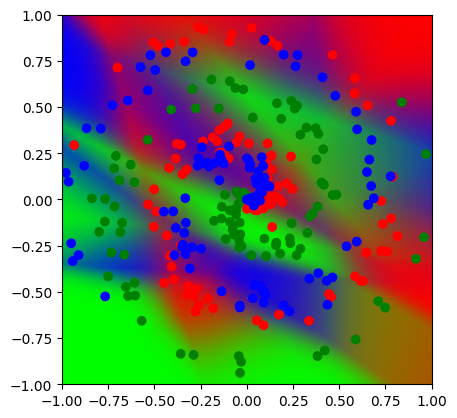

In [49]:
# SOL EJ 29b

from tqdm import tqdm

nnfs.init()
X, y = spiral_data(samples=100, classes=3)

dense1 = Layer_Dense(n_inputs=X.shape[1], n_neuronas=64)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(n_inputs=64, n_neuronas=3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

optimizer = Optimizer_SGD(decay=1e-3)
precision_func = PrecisionMetric()

# Entrenamiento
n_steps = int(1e4)
pbar = tqdm(range(n_steps))
for step in pbar:
    # Paso de forward
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss_activation.forward(dense2.output, y)

    # Paso de backward
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # Actualización de los pesos (creo que en el vídeo no llama a los dos métodos pre y post)
    optimizer.pre_update_params()
    optimizer.update_params(layer=dense2)
    optimizer.update_params(layer=dense1)
    optimizer.post_update_params()

    if step % 1000 == 0:
        loss_val = loss_activation.loss.calculate(output=loss_activation.output, y=y)
        prec_metric = precision_function(y_pred=loss_activation.output, y_true=y)
        pbar.set_postfix(
            {
                "lr": optimizer.current_learning_rate,
                "loss": f"{loss_val:.4f}",
                "prec": f"{prec_metric:.4f}",
            }
        )

model = [dense1, activation1, dense2, loss_activation]
num_points = 100
plot_prediction_performance_spiral(model, X, y, num_points)

## Ejercicio 30: Descenso de gradiente con momentum

 - **30.a** Extiende la implementación de la clase ```Optimizer_SGD``` que hiciste en el ejercicio 29 para que incluya el mecanismo de *momentum*. Sigue la siguiente plantilla de desarrollo:

In [50]:
# SOL EJ 30a


# Optimizador SGD con momentum
class Optimizer_SGD:

    def __init__(self, learning_rate=1.0, decay=0.0, momentum=0.0):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.momentum = momentum

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate / (
                1 + self.decay * self.iterations
            )

    def update_params(self, layer: Layer_Dense):

        # Si usamos momentum, creamos arrays de momentum si no existen. Inicializados en ceros
        if self.momentum:
            if not hasattr(layer, "weight_momentums"):
                layer.weight_momentums = np.zeros_like(layer.weights)
                layer.bias_momentums = np.zeros_like(layer.biases)

            # Calcular actualizaciones de pesos y sesgos con momentum
            weight_updates = (
                self.momentum * layer.weight_momentums
                - self.current_learning_rate * layer.dweights
            )
            layer.weight_momentums = weight_updates

            bias_updates = (
                self.momentum * layer.bias_momentums
                - self.current_learning_rate * layer.dbiases
            )
            layer.bias_momentums = bias_updates

        # Calcular actualizaciones de pesos y sesgos sin momentum (como en ejercicios anteriores)
        else:
            weight_updates = layer.dweights * self.current_learning_rate
            bias_updates = layer.dbiases * self.current_learning_rate

        # Actualizar pesos y sesgos usando actualizaciones con o sin momentum
        layer.weights += weight_updates
        layer.biases += bias_updates

    def post_update_params(self):
        self.iterations += 1

  - **30.b** Partiendo del código al que llegaste en el ejercicio 29, prueba el mecanismo de momentum que acabas de implementar. Probar con un *decay* de $10^{-3}$ y un *momentum* de $0.5$ y luego de $0.9$. ¿Se mejoran los resultados en comparación con los que obtuviste en el ejercicio 29? Recuerda visiualizar los resultados como se explica en el ejercicio 27.

100%|██████████| 10000/10000 [00:06<00:00, 1545.41it/s, lr=0.1, loss=0.1344, prec=0.9567] 


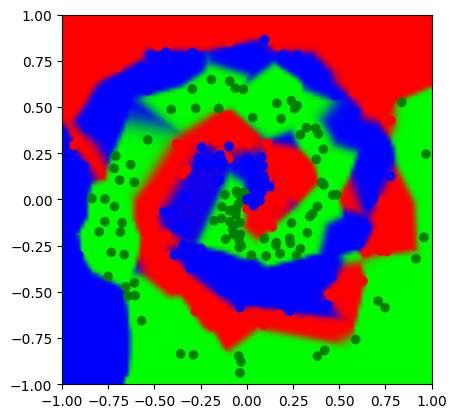

In [51]:
# SOL EJ 30b

from tqdm import tqdm

nnfs.init()
X, y = spiral_data(samples=100, classes=3)

dense1 = Layer_Dense(n_inputs=X.shape[1], n_neuronas=64)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(n_inputs=64, n_neuronas=3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

optimizer = Optimizer_SGD(decay=1e-3, momentum=0.9)
precision_func = PrecisionMetric()

# Entrenamiento
n_steps = int(1e4)
pbar = tqdm(range(n_steps))
for step in pbar:
    # Paso de forward
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss_activation.forward(dense2.output, y)

    # Paso de backward
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # Actualización de los pesos (creo que en el vídeo no llama a los dos métodos pre y post)
    optimizer.pre_update_params()
    optimizer.update_params(layer=dense2)
    optimizer.update_params(layer=dense1)
    optimizer.post_update_params()

    if step % 1000 == 0:
        loss_val = loss_activation.loss.calculate(output=loss_activation.output, y=y)
        prec_metric = precision_function(y_pred=loss_activation.output, y_true=y)
        pbar.set_postfix(
            {
                "lr": optimizer.current_learning_rate,
                "loss": f"{loss_val:.4f}",
                "prec": f"{prec_metric:.4f}",
            }
        )

model = [dense1, activation1, dense2, loss_activation]
num_points = 100
plot_prediction_performance_spiral(model, X, y, num_points)

## Ejercicio 31: RMS Prop

 - **31.a** Partiendo de la clase que implementaste en el ejercicio anterior, programa una nueva clase llamada ```Optimizer_RMSprop``` que implemente este optimizador. RMSProp utiliza una media móvil de la caché:

    ```python
    cache = rho * cache + (1 - rho) * gradient ** 2
    ```

    Que luego se usará en la actualización de cada parámetro individual como:

    ```python
    parm_updates = learning_rate * parm_gradient / (sqrt(cache) + eps)
    ```
    Sigue la siguiente plantilla de desarrollo:

In [52]:
# SOL EJ 31a


# RMSprop con momentum
class Optimizer_RMSprop:

    def __init__(self, learning_rate=0.001, decay=0.0, epsilon=1e-7, rho=0.9):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.rho = rho

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate / (
                1 + self.decay * self.iterations
            )

    # Actualizar parámetros usando RMSprop con momentum
    def update_params(self, layer: Layer_Dense):
        # Si los arrays de caché no existen, crearlos llenos de ceros
        if not hasattr(layer, "weight_cache"):
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_cache = np.zeros_like(layer.biases)

        # Actualizar la caché con los gradientes actuales al cuadrado
        layer.weight_cache = (
            self.rho * layer.weight_cache + (1 - self.rho) * layer.dweights**2
        )
        layer.bias_cache = (
            self.rho * layer.bias_cache + (1 - self.rho) * layer.dbiases**2
        )

        # Actualizar pesos y sesgos usando RMSprop con momentum
        layer.weights += (
            -self.current_learning_rate
            * layer.dweights
            / (np.sqrt(layer.weight_cache) + self.epsilon)
        )
        layer.biases += (
            -self.current_learning_rate
            * layer.dbiases
            / (np.sqrt(layer.bias_cache) + self.epsilon)
        )

    def post_update_params(self):
        self.iterations += 1

  - **31.b** Partiendo del código al que llegaste en el ejercicio 30, prueba el optimizador que acabas de implementar. Prueba primero con un *decay* de $10^{-4}$ y el resto de parámetros por defecto. Prueba luego con ```learning_rate=0.02, decay=1e-5, rho=0.999``` ¿Se consigue mejorar los resultados en comparación con los del ejercicio 30? Recuerda visiualizar los resultados como se explica en el ejercicio 27.

100%|██████████| 10000/10000 [00:07<00:00, 1427.82it/s, lr=0.0183, loss=0.2812, prec=0.8800]


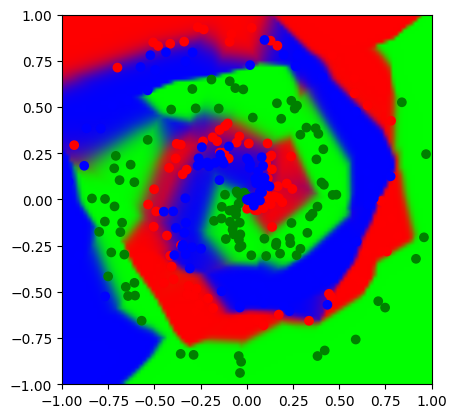

In [53]:
# SOL EJ 31b

from tqdm import tqdm

nnfs.init()
X, y = spiral_data(samples=100, classes=3)

dense1 = Layer_Dense(n_inputs=X.shape[1], n_neuronas=64)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(n_inputs=64, n_neuronas=3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

optimizer = Optimizer_RMSprop(learning_rate=0.02, decay=1e-5, rho=0.999)
precision_func = PrecisionMetric()

# Entrenamiento
n_steps = int(1e4)
pbar = tqdm(range(n_steps))
for step in pbar:
    # Paso de forward
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss_activation.forward(dense2.output, y)

    # Paso de backward
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # Actualización de los pesos (creo que en el vídeo no llama a los dos métodos pre y post)
    optimizer.pre_update_params()
    optimizer.update_params(layer=dense2)
    optimizer.update_params(layer=dense1)
    optimizer.post_update_params()

    if step % 1000 == 0:
        loss_val = loss_activation.loss.calculate(output=loss_activation.output, y=y)
        prec_metric = precision_function(y_pred=loss_activation.output, y_true=y)
        pbar.set_postfix(
            {
                "lr": optimizer.current_learning_rate,
                "loss": f"{loss_val:.4f}",
                "prec": f"{prec_metric:.4f}",
            }
        )

model = [dense1, activation1, dense2, loss_activation]
num_points = 100
plot_prediction_performance_spiral(model, X, y, num_points)

## Ejercicio 32: Adam

 - **32.a** Partiendo de la clase que implementaste en el ejercicio anterior, programa una nueva clase llamada ```Optimizer_Adam``` que implemente este optimizador. Adam añade a RMSProp el mecanismo de momentum ($\beta_1$). También añade además un mecanismo de corrección de sesgo, dividiendo tanto el momentum como el caché por $1-\beta_1^{step}$.

In [54]:
# SOL EJ 32a


# Optimizador Adam
class Optimizer_Adam:

    # Inicializar el optimizador - establecer configuraciones
    def __init__(
        self, learning_rate=0.001, decay=0.0, epsilon=1e-7, beta_1=0.9, beta_2=0.999
    ):
        self.learning_rate = learning_rate
        self.current_learning_rate = learning_rate
        self.decay = decay
        self.iterations = 0
        self.epsilon = epsilon
        self.beta_1 = beta_1  # momentum, y para la corrección descrita arriba
        self.beta_2 = (
            beta_2  # renombrar el antiguo rho de RMSProp -> usado para la caché
        )

    def pre_update_params(self):
        if self.decay:
            self.current_learning_rate = self.learning_rate / (
                1 + self.decay * self.iterations
            )

    def update_params(self, layer: Layer_Dense):

        # Si la capa no contiene arrays de caché, crearlos llenos de ceros
        if not hasattr(layer, "weight_cache"):
            layer.weight_momentums = np.zeros_like(layer.weights)
            layer.weight_cache = np.zeros_like(layer.weights)
            layer.bias_momentums = np.zeros_like(layer.biases)
            layer.bias_cache = np.zeros_like(layer.biases)

        # Actualizar el momentum con los gradientes actuales (m_t)
        layer.weight_momentums = (
            self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights
        )
        layer.bias_momentums = (
            self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases
        )

        # Actualizar la caché con los gradientes actuales al cuadrado (v_t)
        layer.weight_cache = (
            self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2
        )
        layer.bias_cache = (
            self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2
        )

        # Obtener el momentum y la caché corregidos (self.iteration es 0 en el primer paso, y necesitamos empezar con 1 aquí) -> así que dividir por (1 - self.beta_1 ** (self.iterations + 1))
        weight_momentums_corrected = layer.weight_momentums / (
            1 - self.beta_1 ** (self.iterations + 1)
        )
        bias_momentums_corrected = layer.bias_momentums / (
            1 - self.beta_1 ** (self.iterations + 1)
        )
        weight_cache_corrected = layer.weight_cache / (
            1 - self.beta_2 ** (self.iterations + 1)
        )
        bias_cache_corrected = layer.bias_cache / (
            1 - self.beta_2 ** (self.iterations + 1)
        )

        # Actualización de parámetros de SGD + normalización con la caché enraizada
        layer.weights += (
            -self.current_learning_rate
            * weight_momentums_corrected
            / (np.sqrt(weight_cache_corrected) + self.epsilon)
        )
        layer.biases += (
            -self.current_learning_rate
            * bias_momentums_corrected
            / (np.sqrt(bias_cache_corrected) + self.epsilon)
        )

    def post_update_params(self):
        self.iterations += 1

  - **32.b** Partiendo del código al que llegaste en el ejercicio 31, prueba el optimizador que acabas de implementar. Prueba primero con ```Optimizer_Adam(learning_rate=0.02, decay=1e-5)```, y luego con ```Optimizer_Adam(learning_rate=0.05, decay=5e-7)```. ¿Se consigue mejorar los resultados en comparación con los del ejercicio 31? Recuerda visiualizar los resultados como se explica en el ejercicio 27.

  0%|          | 0/10000 [00:00<?, ?it/s, lr=0.05, loss=1.0986, prec=0.3600]

100%|██████████| 10000/10000 [00:07<00:00, 1337.92it/s, lr=0.0498, loss=0.0732, prec=0.9733]


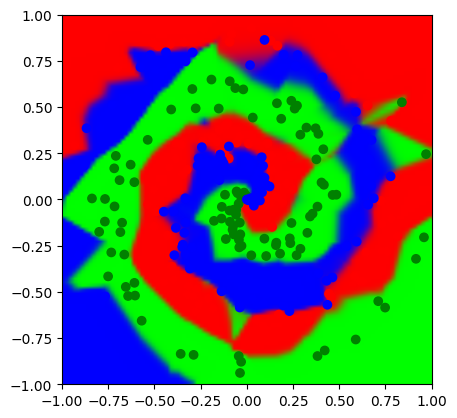

In [55]:
# SOL EJ 32b

from tqdm import tqdm

nnfs.init()
X, y = spiral_data(samples=100, classes=3)

dense1 = Layer_Dense(n_inputs=X.shape[1], n_neuronas=64)
activation1 = Activation_ReLU()

dense2 = Layer_Dense(n_inputs=64, n_neuronas=3)
loss_activation = Activation_Softmax_Loss_CategoricalCrossentropy()

optimizer = Optimizer_Adam(learning_rate=0.05, decay=5e-7)
precision_func = PrecisionMetric()

# Entrenamiento
n_steps = int(1e4)
pbar = tqdm(range(n_steps))
for step in pbar:
    # Paso de forward
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss_activation.forward(dense2.output, y)

    # Paso de backward
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # Actualización de los pesos (creo que en el vídeo no llama a los dos métodos pre y post)
    optimizer.pre_update_params()
    optimizer.update_params(layer=dense2)
    optimizer.update_params(layer=dense1)
    optimizer.post_update_params()

    if step % 1000 == 0:
        loss_val = loss_activation.loss.calculate(output=loss_activation.output, y=y)
        prec_metric = precision_function(y_pred=loss_activation.output, y_true=y)
        pbar.set_postfix(
            {
                "lr": optimizer.current_learning_rate,
                "loss": f"{loss_val:.4f}",
                "prec": f"{prec_metric:.4f}",
            }
        )

model = [dense1, activation1, dense2, loss_activation]
num_points = 100
plot_prediction_performance_spiral(model, X, y, num_points)

 - **32.c** Interpreta los resultados que acabas de obtener. ¿Crees que la red ha aprendido correctamente la naturaleza de los datos de entrenamiento? Si no es así, investiga qué puede estar pasando y discute posibles soluciones (no es necesario implementar nada).

In [56]:
# SOL EJ 32c

Analizando los resultados obtenidos por la figura, se puede observar que la red si que aprende, el problema es que se sobreajusta a los datos. Sabemos cómo se construyen los datos, debería formar una espiral de 3 zonas. Aquí podemos ver que más o menos detecta las zonas, pero que hay partes que debido al ruido existen datos de otra clase y la red decidió que la zona alrededor de dicho punto es de la clase de ese punto, lo cual es completamente falso.